# 04 — تحليل FP-Growth على سلال المملكة المتحدة

ينفذ هذا Notebook البحث المحروس عن Minimum Support، ثم FP-Growth وتوليد Association Rules بواسطة وظائف المشروع القابلة لإعادة الاستخدام. كل النتائج أدناه ناتجة من 17,901 معاملة UK، وليست قيماً مكتوبة يدوياً.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

from src.data.paths import PROJECT_ROOT, project_path
from src.mining.basket_loader import load_prepared_basket
from src.mining.pipeline import run_fpgrowth_experiment

assert Path.cwd().resolve() == PROJECT_ROOT
assert ".venv" in sys.executable
prepared = load_prepared_basket()
assert prepared.matrix.shape == (17_901, 3_791)
assert set(prepared.matrix.data.tolist()) == {1}
print(f"UK basket: {prepared.transaction_count:,} × {prepared.product_count:,}; nnz={prepared.matrix.nnz:,}")

UK basket: 17,901 × 3,791; nnz=473,636


## معنى Support count

Support النسبي يقيس نسبة المعاملات، بينما Support count هو العدد الفعلي. يستخدم المشروع `ceil(support × 17,901)` كحد أدنى محافظ. صُممت التجربة قبل التعدين في `MINING_EXPERIMENT_DESIGN.md`، مع `max_len=3` وحدود ناعمة للوقت والذاكرة وحجم النتائج.

## تنفيذ البحث المحروس والتجربة النهائية

In [2]:
experiment = run_fpgrowth_experiment()
experiment

FPGrowthExperimentSummary(minimum_support=0.005, minimum_support_count=90, minimum_confidence=0.7, minimum_lift=1.2, maximum_length=3, frequent_itemset_count=18681, all_rule_count=63446, selected_rule_count=3423, runtime_seconds=23.048461799975485)

In [3]:
sweep = pd.read_csv(project_path("outputs", "tables", "fpgrowth_threshold_sweep.csv"))
metadata = json.loads(project_path("outputs", "tables", "fpgrowth_run_metadata.json").read_text(encoding="utf-8"))
display(sweep)
display(pd.DataFrame({"parameter": metadata.keys(), "value": [str(v) for v in metadata.values()]}))

,minimum_support,minimum_support_count,frequent_itemset_count,length_1_count,length_2_count,length_3_count,maximum_observed_length,runtime_seconds,rss_before_bytes,rss_after_bytes,approximate_rss_delta_bytes,memory_measurement,rule_generation_attempted,rule_generation_status,rule_count_confidence_0_30,rule_count_confidence_0_50,rule_count_confidence_0_70,execution_status,stop_reason,maximum_length
0,0.0500,896,38,38,0,0,1,0.453592,192188416,191414272,-774144,approximate process RSS before/after; not peak...,False,not_applicable,0,0,0,success,NaN,3
1,0.0300,538,149,134,15,0,2,0.924896,191635456,209461248,17825792,approximate process RSS before/after; not peak...,True,success,28,17,5,success,NaN,3
2,0.0200,359,414,303,106,5,3,1.588019,209833984,238649344,28815360,approximate process RSS before/after; not peak...,True,success,203,77,17,success,NaN,3
3,0.0150,269,800,485,262,53,3,2.432078,239177728,262094848,22917120,approximate process RSS before/after; not peak...,True,success,568,247,54,success,NaN,3
4,0.0100,180,2199,827,1041,331,3,4.496283,263921664,298938368,35016704,approximate process RSS before/after; not peak...,True,success,1999,991,322,success,NaN,3
5,0.0075,135,4969,1113,2700,1156,3,8.663269,310398976,325521408,15122432,approximate process RSS before/after; not peak...,True,success,5066,2587,848,success,NaN,3
6,0.0050,90,18681,1564,9814,7303,3,17.463750,355553280,376070144,20516864,approximate process RSS before/after; not peak...,True,success,23417,12378,3468,success,NaN,3


,parameter,value
0,algorithm,mlxtend.frequent_patterns.fpgrowth
1,approximate_rss_after_bytes,375455744
2,approximate_rss_before_bytes,320569344
3,approximate_rss_delta_bytes,54886400
4,association_rule_count,63446
5,environment,"{'mlxtend': '0.25.0', 'pandas': '3.0.3', 'pyth..."
6,frequent_itemset_count,18681
7,interpretation_minimum_lift,1.2
8,itemset_length_distribution,"{'1': 1564, '2': 9814, '3': 7303}"
9,maximum_itemset_length,3


اختيرت 0.5% لأنها أدنى عتبة ناجحة في الشبكة وبقيت دون الضوابط، مع أنماط ثنائية وثلاثية وقواعد قابلة للإدارة. تعادل 90 معاملة. اختيرت Confidence=0.70 لأنها أعلى قيمة مرشحة أبقت أكثر من 25 قاعدة، ويستخدم Lift≥1.20 للتفسير. القيد `max_len=3` معلن ويعني أن الأنماط الأطول لم تُنقّب.

## Frequent Itemsets

In [4]:
lengths = pd.read_csv(project_path("outputs", "tables", "frequent_itemsets_length_summary.csv"))
itemsets = pd.read_csv(project_path("outputs", "tables", "frequent_itemsets_fpgrowth.csv"))
display(lengths)
display(itemsets.head(15))
assert (itemsets.support_count == (itemsets.support * prepared.transaction_count).round().astype(int)).all()

,itemset_length,frequent_itemset_count,minimum_support,maximum_support,minimum_support_count,maximum_support_count
0,1,1564,0.005028,0.121278,90,2171
1,2,9814,0.005028,0.043852,90,785
2,3,7303,0.005028,0.027484,90,492


,itemset_key,product_codes,product_descriptions,itemset_length,support,support_count
0,85123A,"[""85123A""]","[""85123A — WHITE HANGING HEART T-LIGHT HOLDER""]",1,0.121278,2171
1,85099B,"[""85099B""]","[""85099B — JUMBO BAG RED RETROSPOT""]",1,0.108095,1935
2,22423,"[""22423""]","[""22423 — REGENCY CAKESTAND 3 TIER""]",1,0.094129,1685
3,47566,"[""47566""]","[""47566 — PARTY BUNTING""]",1,0.088989,1593
4,20725,"[""20725""]","[""20725 — LUNCH BAG RED RETROSPOT""]",1,0.077761,1392
5,84879,"[""84879""]","[""84879 — ASSORTED COLOUR BIRD ORNAMENT""]",1,0.076588,1371
6,22197,"[""22197""]","[""22197 — POPCORN HOLDER""]",1,0.072398,1296
7,22720,"[""22720""]","[""22720 — SET OF 3 CAKE TINS PANTRY DESIGN""]",1,0.069326,1241
8,22457,"[""22457""]","[""22457 — NATURAL SLATE HEART CHALKBOARD""]",1,0.068097,1219
9,20727,"[""20727""]","[""20727 — LUNCH BAG BLACK SKULL.""]",1,0.067929,1216


## Association Rules ومقاييسها

- **Support:** انتشار الطرفين معاً.
- **Confidence:** احتمال ظهور Consequent داخل معاملات Antecedent.
- **Lift:** يقارن Confidence بخط أساس Consequent؛ القيمة 1 تعني تقريباً الاستقلال.
- **Leverage:** فرق الدعم المشترك عن المتوقع تحت الاستقلال.
- **Conviction:** يقارن فشل القاعدة المتوقع والفعلي، ويحتاج حذراً عند القيم الحدية.

لا يثبت أي مقياس السببية أو الترتيب الزمني داخل الفاتورة.

In [5]:
rules = pd.read_csv(project_path("outputs", "tables", "association_rules_all.csv"))
selected = pd.read_csv(project_path("outputs", "tables", "association_rules_selected.csv"))
metric_summary = pd.read_csv(project_path("outputs", "tables", "rule_metric_summary.csv"))
display(metric_summary)
display(selected.head(12))
print(f"All rules: {len(rules):,}; selected non-redundant rules: {len(selected):,}")

,metric,total_count,finite_count,infinite_count,missing_count,minimum,median,mean,maximum
0,antecedent_support,63446,63446,0,0,0.005307,0.031730,0.037113,0.121278
1,consequent_support,63446,63446,0,0,0.005307,0.031730,0.037113,0.121278
2,support,63446,63446,0,0,0.005028,0.005866,0.006635,0.043852
3,confidence,63446,63446,0,0,0.041456,0.212625,0.289879,0.973684
4,lift,63446,63446,0,0,1.052649,7.807065,9.924308,101.268514
5,leverage,63446,63446,0,0,0.000436,0.005046,0.005556,0.036854
6,conviction,63446,63446,0,0,1.004386,1.220056,1.597035,37.286744


,rule_key,antecedent_codes,antecedent_descriptions,consequent_codes,consequent_descriptions,antecedent_length,consequent_length,antecedent_support,consequent_support,support,support_count,confidence,lift,leverage,conviction,conviction_is_infinite,interpretation,key_metrics_finite,conviction_valid,is_redundant
0,21801 => 21802 | 21803,"[""21801""]","[""21801 — CHRISTMAS TREE DECORATION WITH BELL""]","[""21802"", ""21803""]","[""21802 — CHRISTMAS TREE HEART DECORATION"", ""2...",1,2,0.006983,0.007821,0.005530,99,0.792000,101.268514,0.005476,4.770092,False,Among transactions containing [21801 — CHRISTM...,True,True,False
1,21802 | 21803 => 21801,"[""21802"", ""21803""]","[""21802 — CHRISTMAS TREE HEART DECORATION"", ""2...","[""21801""]","[""21801 — CHRISTMAS TREE DECORATION WITH BELL""]",2,1,0.007821,0.006983,0.005530,99,0.707143,101.268514,0.005476,3.390790,False,Among transactions containing [21802 — CHRISTM...,True,True,False
2,23291 => 23289,"[""23291""]","[""23291 — DOLLY GIRL CHILDRENS CUP""]","[""23289""]","[""23289 — DOLLY GIRL CHILDRENS BOWL""]",1,1,0.007877,0.007709,0.005866,105,0.744681,96.598057,0.005805,3.886473,False,Among transactions containing [23291 — DOLLY G...,True,True,False
3,23289 => 23291,"[""23289""]","[""23289 — DOLLY GIRL CHILDRENS BOWL""]","[""23291""]","[""23291 — DOLLY GIRL CHILDRENS CUP""]",1,1,0.007709,0.007877,0.005866,105,0.760870,96.598057,0.005805,4.148879,False,Among transactions containing [23289 — DOLLY G...,True,True,False
4,23286 | 23288 => 23285,"[""23286"", ""23288""]","[""23286 — BLUE VINTAGE SPOT BEAKER"", ""23288 — ...","[""23285""]","[""23285 — PINK VINTAGE SPOT BEAKER""]",2,1,0.006424,0.008659,0.005363,96,0.834783,96.409313,0.005307,6.000223,False,Among transactions containing [23286 — BLUE VI...,True,True,False
5,21987 => 21988,"[""21987""]","[""21987 — PACK OF 6 SKULL PAPER CUPS""]","[""21988""]","[""21988 — PACK OF 6 SKULL PAPER PLATES""]",1,1,0.006704,0.008100,0.005195,93,0.775000,95.677759,0.005141,4.408444,False,Among transactions containing [21987 — PACK OF...,True,True,False
6,21801 | 21803 => 21802,"[""21801"", ""21803""]","[""21801 — CHRISTMAS TREE DECORATION WITH BELL""...","[""21802""]","[""21802 — CHRISTMAS TREE HEART DECORATION""]",2,1,0.005810,0.009999,0.005530,99,0.951923,95.197626,0.005472,20.592012,False,Among transactions containing [21801 — CHRISTM...,True,True,False
7,23286 | 23288 => 23287,"[""23286"", ""23288""]","[""23286 — BLUE VINTAGE SPOT BEAKER"", ""23288 — ...","[""23287""]","[""23287 — RED VINTAGE SPOT BEAKER""]",2,1,0.006424,0.008715,0.005195,93,0.808696,92.797826,0.005139,5.181719,False,Among transactions containing [23286 — BLUE VI...,True,True,False
8,23286 | 23287 => 23288,"[""23286"", ""23287""]","[""23286 — BLUE VINTAGE SPOT BEAKER"", ""23287 — ...","[""23288""]","[""23288 — GREEN VINTAGE SPOT BEAKER""]",2,1,0.006424,0.008770,0.005195,93,0.808696,92.206757,0.005139,5.181427,False,Among transactions containing [23286 — BLUE VI...,True,True,False
9,23285 | 23286 => 23288,"[""23285"", ""23286""]","[""23285 — PINK VINTAGE SPOT BEAKER"", ""23286 — ...","[""23288""]","[""23288 — GREEN VINTAGE SPOT BEAKER""]",2,1,0.006759,0.008770,0.005363,96,0.793388,90.461441,0.005304,4.797551,False,Among transactions containing [23285 — PINK VI...,True,True,False


All rules: 63,446; selected non-redundant rules: 3,423


## لماذا قد تكون Confidence المرتفعة مضللة؟

In [6]:
high_confidence_lowest_lift = (
    rules.loc[rules.confidence >= metadata["minimum_confidence"]]
    .sort_values(["lift", "support", "rule_key"])
    [["rule_key", "support", "confidence", "lift", "consequent_support"]]
    .head(10)
)
display(high_confidence_lowest_lift)

,rule_key,support,confidence,lift,consequent_support
55101,21934 | 22457 => 85123A,0.005139,0.702290,5.790739,0.121278
25210,21733 | 22469 => 85123A,0.006201,0.702532,5.792731,0.121278
350,22804 => 85123A,0.017653,0.713318,5.881672,0.121278
47901,21733 | 22457 => 85123A,0.005307,0.730769,6.025564,0.121278
18688,21733 | 22470 => 85123A,0.006704,0.731707,6.033299,0.121278
57700,20712 | 21977 => 85099B,0.005084,0.700000,6.475814,0.108095
57701,21731 | 22219 => 85099B,0.005084,0.700000,6.475814,0.108095
57702,21935 | 85131D => 85099B,0.005084,0.700000,6.475814,0.108095
42021,21790 | 21931 => 85099B,0.005475,0.700000,6.475814,0.108095
42022,21934 | 21993 => 85099B,0.005475,0.700000,6.475814,0.108095


يمكن أن تكون Confidence مرتفعة لأن Consequent شائع أساساً. لذلك لا تختار السياسة القواعد قبل قراءة Lift وSupport count وLeverage، وتبقي التفسير وصفياً وغير سببي.

## ترتيبات متعددة للقواعد

In [7]:
for filename in ["top_rules_by_support.csv", "top_rules_by_confidence.csv", "top_rules_by_lift.csv"]:
    print(filename)
    display(pd.read_csv(project_path("outputs", "tables", filename)).head(10))

top_rules_by_support.csv


,rule_key,antecedent_codes,antecedent_descriptions,consequent_codes,consequent_descriptions,antecedent_length,consequent_length,antecedent_support,consequent_support,support,support_count,confidence,lift,leverage,conviction,conviction_is_infinite,interpretation,key_metrics_finite,conviction_valid,is_redundant
0,22697 => 22699,"[""22697""]","[""22697 — GREEN REGENCY TEACUP AND SAUCER""]","[""22699""]","[""22699 — ROSES REGENCY TEACUP AND SAUCER""]",1,1,0.052064,0.053405,0.039104,700,0.751073,14.063763,0.036323,3.802701,False,Among transactions containing [22697 — GREEN R...,True,True,False
1,22699 => 22697,"[""22699""]","[""22699 — ROSES REGENCY TEACUP AND SAUCER""]","[""22697""]","[""22697 — GREEN REGENCY TEACUP AND SAUCER""]",1,1,0.053405,0.052064,0.039104,700,0.732218,14.063763,0.036323,3.539948,False,Among transactions containing [22699 — ROSES R...,True,True,False
2,22698 => 22697,"[""22698""]","[""22698 — PINK REGENCY TEACUP AND SAUCER""]","[""22697""]","[""22697 — GREEN REGENCY TEACUP AND SAUCER""]",1,1,0.039216,0.052064,0.032177,576,0.820513,15.759657,0.030135,5.281357,False,Among transactions containing [22698 — PINK RE...,True,True,False
3,22698 => 22699,"[""22698""]","[""22698 — PINK REGENCY TEACUP AND SAUCER""]","[""22699""]","[""22699 — ROSES REGENCY TEACUP AND SAUCER""]",1,1,0.039216,0.053405,0.030445,545,0.776353,14.537134,0.028351,4.232547,False,Among transactions containing [22698 — PINK RE...,True,True,False
4,23300 => 23301,"[""23300""]","[""23300 — GARDENERS KNEELING PAD CUP OF TEA""]","[""23301""]","[""23301 — GARDENERS KNEELING PAD KEEP CALM""]",1,1,0.041897,0.050165,0.030222,541,0.721333,14.379274,0.028120,3.408500,False,Among transactions containing [23300 — GARDENE...,True,True,False
5,22698 | 22699 => 22697,"[""22698"", ""22699""]","[""22698 — PINK REGENCY TEACUP AND SAUCER"", ""22...","[""22697""]","[""22697 — GREEN REGENCY TEACUP AND SAUCER""]",2,1,0.030445,0.052064,0.027484,492,0.902752,17.339237,0.025899,9.747642,False,Among transactions containing [22698 — PINK RE...,True,True,False
6,22697 | 22698 => 22699,"[""22697"", ""22698""]","[""22697 — GREEN REGENCY TEACUP AND SAUCER"", ""2...","[""22699""]","[""22699 — ROSES REGENCY TEACUP AND SAUCER""]",2,1,0.032177,0.053405,0.027484,492,0.854167,15.994181,0.025766,6.490938,False,Among transactions containing [22697 — GREEN R...,True,True,False
7,22697 | 22699 => 22698,"[""22697"", ""22699""]","[""22697 — GREEN REGENCY TEACUP AND SAUCER"", ""2...","[""22698""]","[""22698 — PINK REGENCY TEACUP AND SAUCER""]",2,1,0.039104,0.039216,0.027484,492,0.702857,17.922857,0.025951,3.233409,False,Among transactions containing [22697 — GREEN R...,True,True,False
8,22698 => 22697 | 22699,"[""22698""]","[""22698 — PINK REGENCY TEACUP AND SAUCER""]","[""22697"", ""22699""]","[""22697 — GREEN REGENCY TEACUP AND SAUCER"", ""2...",1,2,0.039216,0.039104,0.027484,492,0.700855,17.922857,0.025951,3.212138,False,Among transactions containing [22698 — PINK RE...,True,True,False
9,22356 => 20724,"[""22356""]","[""22356 — CHARLOTTE BAG PINK POLKADOT""]","[""20724""]","[""20724 — RED RETROSPOT CHARLOTTE BAG""]",1,1,0.037596,0.050444,0.026758,479,0.711738,14.109447,0.024862,3.294078,False,Among transactions containing [22356 — CHARLOT...,True,True,False


top_rules_by_confidence.csv


,rule_key,antecedent_codes,antecedent_descriptions,consequent_codes,consequent_descriptions,antecedent_length,consequent_length,antecedent_support,consequent_support,support,support_count,confidence,lift,leverage,conviction,conviction_is_infinite,interpretation,key_metrics_finite,conviction_valid,is_redundant
0,23172 | 23174 => 23171,"[""23172"", ""23174""]","[""23172 — REGENCY TEA PLATE PINK"", ""23174 — RE...","[""23171""]","[""23171 — REGENCY TEA PLATE GREEN""]",2,1,0.006368,0.018770,0.006201,111,0.973684,51.874765,0.006081,37.286744,False,Among transactions containing [23172 — REGENCY...,True,True,False
1,21934 | 22909 => 21935,"[""21934"", ""22909""]","[""21934 — SKULL SHOULDER BAG"", ""22909 — SET OF...","[""21935""]","[""21935 — SUKI SHOULDER BAG""]",2,1,0.005419,0.028322,0.005251,94,0.969072,34.215702,0.005098,31.417574,False,Among transactions containing [21934 — SKULL S...,True,True,False
2,22916 | 22921 => 22918,"[""22916"", ""22921""]","[""22916 — HERB MARKER THYME"", ""22921 — HERB MA...","[""22918""]","[""22918 — HERB MARKER PARSLEY""]",2,1,0.010279,0.012737,0.009944,178,0.967391,75.952946,0.009813,30.276074,False,Among transactions containing [22916 — HERB MA...,True,True,False
3,22917 | 22921 => 22918,"[""22917"", ""22921""]","[""22917 — HERB MARKER ROSEMARY"", ""22921 — HERB...","[""22918""]","[""22918 — HERB MARKER PARSLEY""]",2,1,0.010223,0.012737,0.009888,177,0.967213,75.938956,0.009758,30.111530,False,Among transactions containing [22917 — HERB MA...,True,True,False
4,22917 | 22921 => 22916,"[""22917"", ""22921""]","[""22917 — HERB MARKER ROSEMARY"", ""22921 — HERB...","[""22916""]","[""22916 — HERB MARKER THYME""]",2,1,0.010223,0.012848,0.009888,177,0.967213,75.278617,0.009756,30.108122,False,Among transactions containing [22917 — HERB MA...,True,True,False
5,21494 | 21934 => 21935,"[""21494"", ""21934""]","[""21494 — ROTATING LEAVES T-LIGHT HOLDER"", ""21...","[""21935""]","[""21935 — SUKI SHOULDER BAG""]",2,1,0.007877,0.028322,0.007597,136,0.964539,34.055646,0.007374,27.401307,False,Among transactions containing [21494 — ROTATIN...,True,True,False
6,22919 | 22921 => 22918,"[""22919"", ""22921""]","[""22919 — HERB MARKER MINT"", ""22921 — HERB MAR...","[""22918""]","[""22918 — HERB MARKER PARSLEY""]",2,1,0.010279,0.012737,0.009888,177,0.961957,75.526244,0.009757,25.950921,False,Among transactions containing [22919 — HERB MA...,True,True,False
7,22916 | 22921 => 22917,"[""22916"", ""22921""]","[""22916 — HERB MARKER THYME"", ""22921 — HERB MA...","[""22917""]","[""22917 — HERB MARKER ROSEMARY""]",2,1,0.010279,0.012904,0.009888,177,0.961957,74.545384,0.009755,25.946515,False,Among transactions containing [22916 — HERB MA...,True,True,False
8,21494 | 22817 => 21935,"[""21494"", ""22817""]","[""21494 — ROTATING LEAVES T-LIGHT HOLDER"", ""22...","[""21935""]","[""21935 — SUKI SHOULDER BAG""]",2,1,0.005754,0.028322,0.005530,99,0.961165,33.936520,0.005367,25.020697,False,Among transactions containing [21494 — ROTATIN...,True,True,False
9,22920 | 22921 => 22918,"[""22920"", ""22921""]","[""22920 — HERB MARKER BASIL"", ""22921 — HERB MA...","[""22918""]","[""22918 — HERB MARKER PARSLEY""]",2,1,0.009888,0.012737,0.009497,170,0.960452,75.408118,0.009371,24.963657,False,Among transactions containing [22920 — HERB MA...,True,True,False


top_rules_by_lift.csv


,rule_key,antecedent_codes,antecedent_descriptions,consequent_codes,consequent_descriptions,antecedent_length,consequent_length,antecedent_support,consequent_support,support,support_count,confidence,lift,leverage,conviction,conviction_is_infinite,interpretation,key_metrics_finite,conviction_valid,is_redundant
0,21801 => 21802 | 21803,"[""21801""]","[""21801 — CHRISTMAS TREE DECORATION WITH BELL""]","[""21802"", ""21803""]","[""21802 — CHRISTMAS TREE HEART DECORATION"", ""2...",1,2,0.006983,0.007821,0.005530,99,0.792000,101.268514,0.005476,4.770092,False,Among transactions containing [21801 — CHRISTM...,True,True,False
1,21802 | 21803 => 21801,"[""21802"", ""21803""]","[""21802 — CHRISTMAS TREE HEART DECORATION"", ""2...","[""21801""]","[""21801 — CHRISTMAS TREE DECORATION WITH BELL""]",2,1,0.007821,0.006983,0.005530,99,0.707143,101.268514,0.005476,3.390790,False,Among transactions containing [21802 — CHRISTM...,True,True,False
2,23291 => 23289,"[""23291""]","[""23291 — DOLLY GIRL CHILDRENS CUP""]","[""23289""]","[""23289 — DOLLY GIRL CHILDRENS BOWL""]",1,1,0.007877,0.007709,0.005866,105,0.744681,96.598057,0.005805,3.886473,False,Among transactions containing [23291 — DOLLY G...,True,True,False
3,23289 => 23291,"[""23289""]","[""23289 — DOLLY GIRL CHILDRENS BOWL""]","[""23291""]","[""23291 — DOLLY GIRL CHILDRENS CUP""]",1,1,0.007709,0.007877,0.005866,105,0.760870,96.598057,0.005805,4.148879,False,Among transactions containing [23289 — DOLLY G...,True,True,False
4,23286 | 23288 => 23285,"[""23286"", ""23288""]","[""23286 — BLUE VINTAGE SPOT BEAKER"", ""23288 — ...","[""23285""]","[""23285 — PINK VINTAGE SPOT BEAKER""]",2,1,0.006424,0.008659,0.005363,96,0.834783,96.409313,0.005307,6.000223,False,Among transactions containing [23286 — BLUE VI...,True,True,False
5,21987 => 21988,"[""21987""]","[""21987 — PACK OF 6 SKULL PAPER CUPS""]","[""21988""]","[""21988 — PACK OF 6 SKULL PAPER PLATES""]",1,1,0.006704,0.008100,0.005195,93,0.775000,95.677759,0.005141,4.408444,False,Among transactions containing [21987 — PACK OF...,True,True,False
6,21801 | 21803 => 21802,"[""21801"", ""21803""]","[""21801 — CHRISTMAS TREE DECORATION WITH BELL""...","[""21802""]","[""21802 — CHRISTMAS TREE HEART DECORATION""]",2,1,0.005810,0.009999,0.005530,99,0.951923,95.197626,0.005472,20.592012,False,Among transactions containing [21801 — CHRISTM...,True,True,False
7,23286 | 23288 => 23287,"[""23286"", ""23288""]","[""23286 — BLUE VINTAGE SPOT BEAKER"", ""23288 — ...","[""23287""]","[""23287 — RED VINTAGE SPOT BEAKER""]",2,1,0.006424,0.008715,0.005195,93,0.808696,92.797826,0.005139,5.181719,False,Among transactions containing [23286 — BLUE VI...,True,True,False
8,23286 | 23287 => 23288,"[""23286"", ""23287""]","[""23286 — BLUE VINTAGE SPOT BEAKER"", ""23287 — ...","[""23288""]","[""23288 — GREEN VINTAGE SPOT BEAKER""]",2,1,0.006424,0.008770,0.005195,93,0.808696,92.206757,0.005139,5.181427,False,Among transactions containing [23286 — BLUE VI...,True,True,False
9,23285 | 23286 => 23288,"[""23285"", ""23286""]","[""23285 — PINK VINTAGE SPOT BEAKER"", ""23286 — ...","[""23288""]","[""23288 — GREEN VINTAGE SPOT BEAKER""]",2,1,0.006759,0.008770,0.005363,96,0.793388,90.461441,0.005304,4.797551,False,Among transactions containing [23285 — PINK VI...,True,True,False


## الرسوم الفعلية

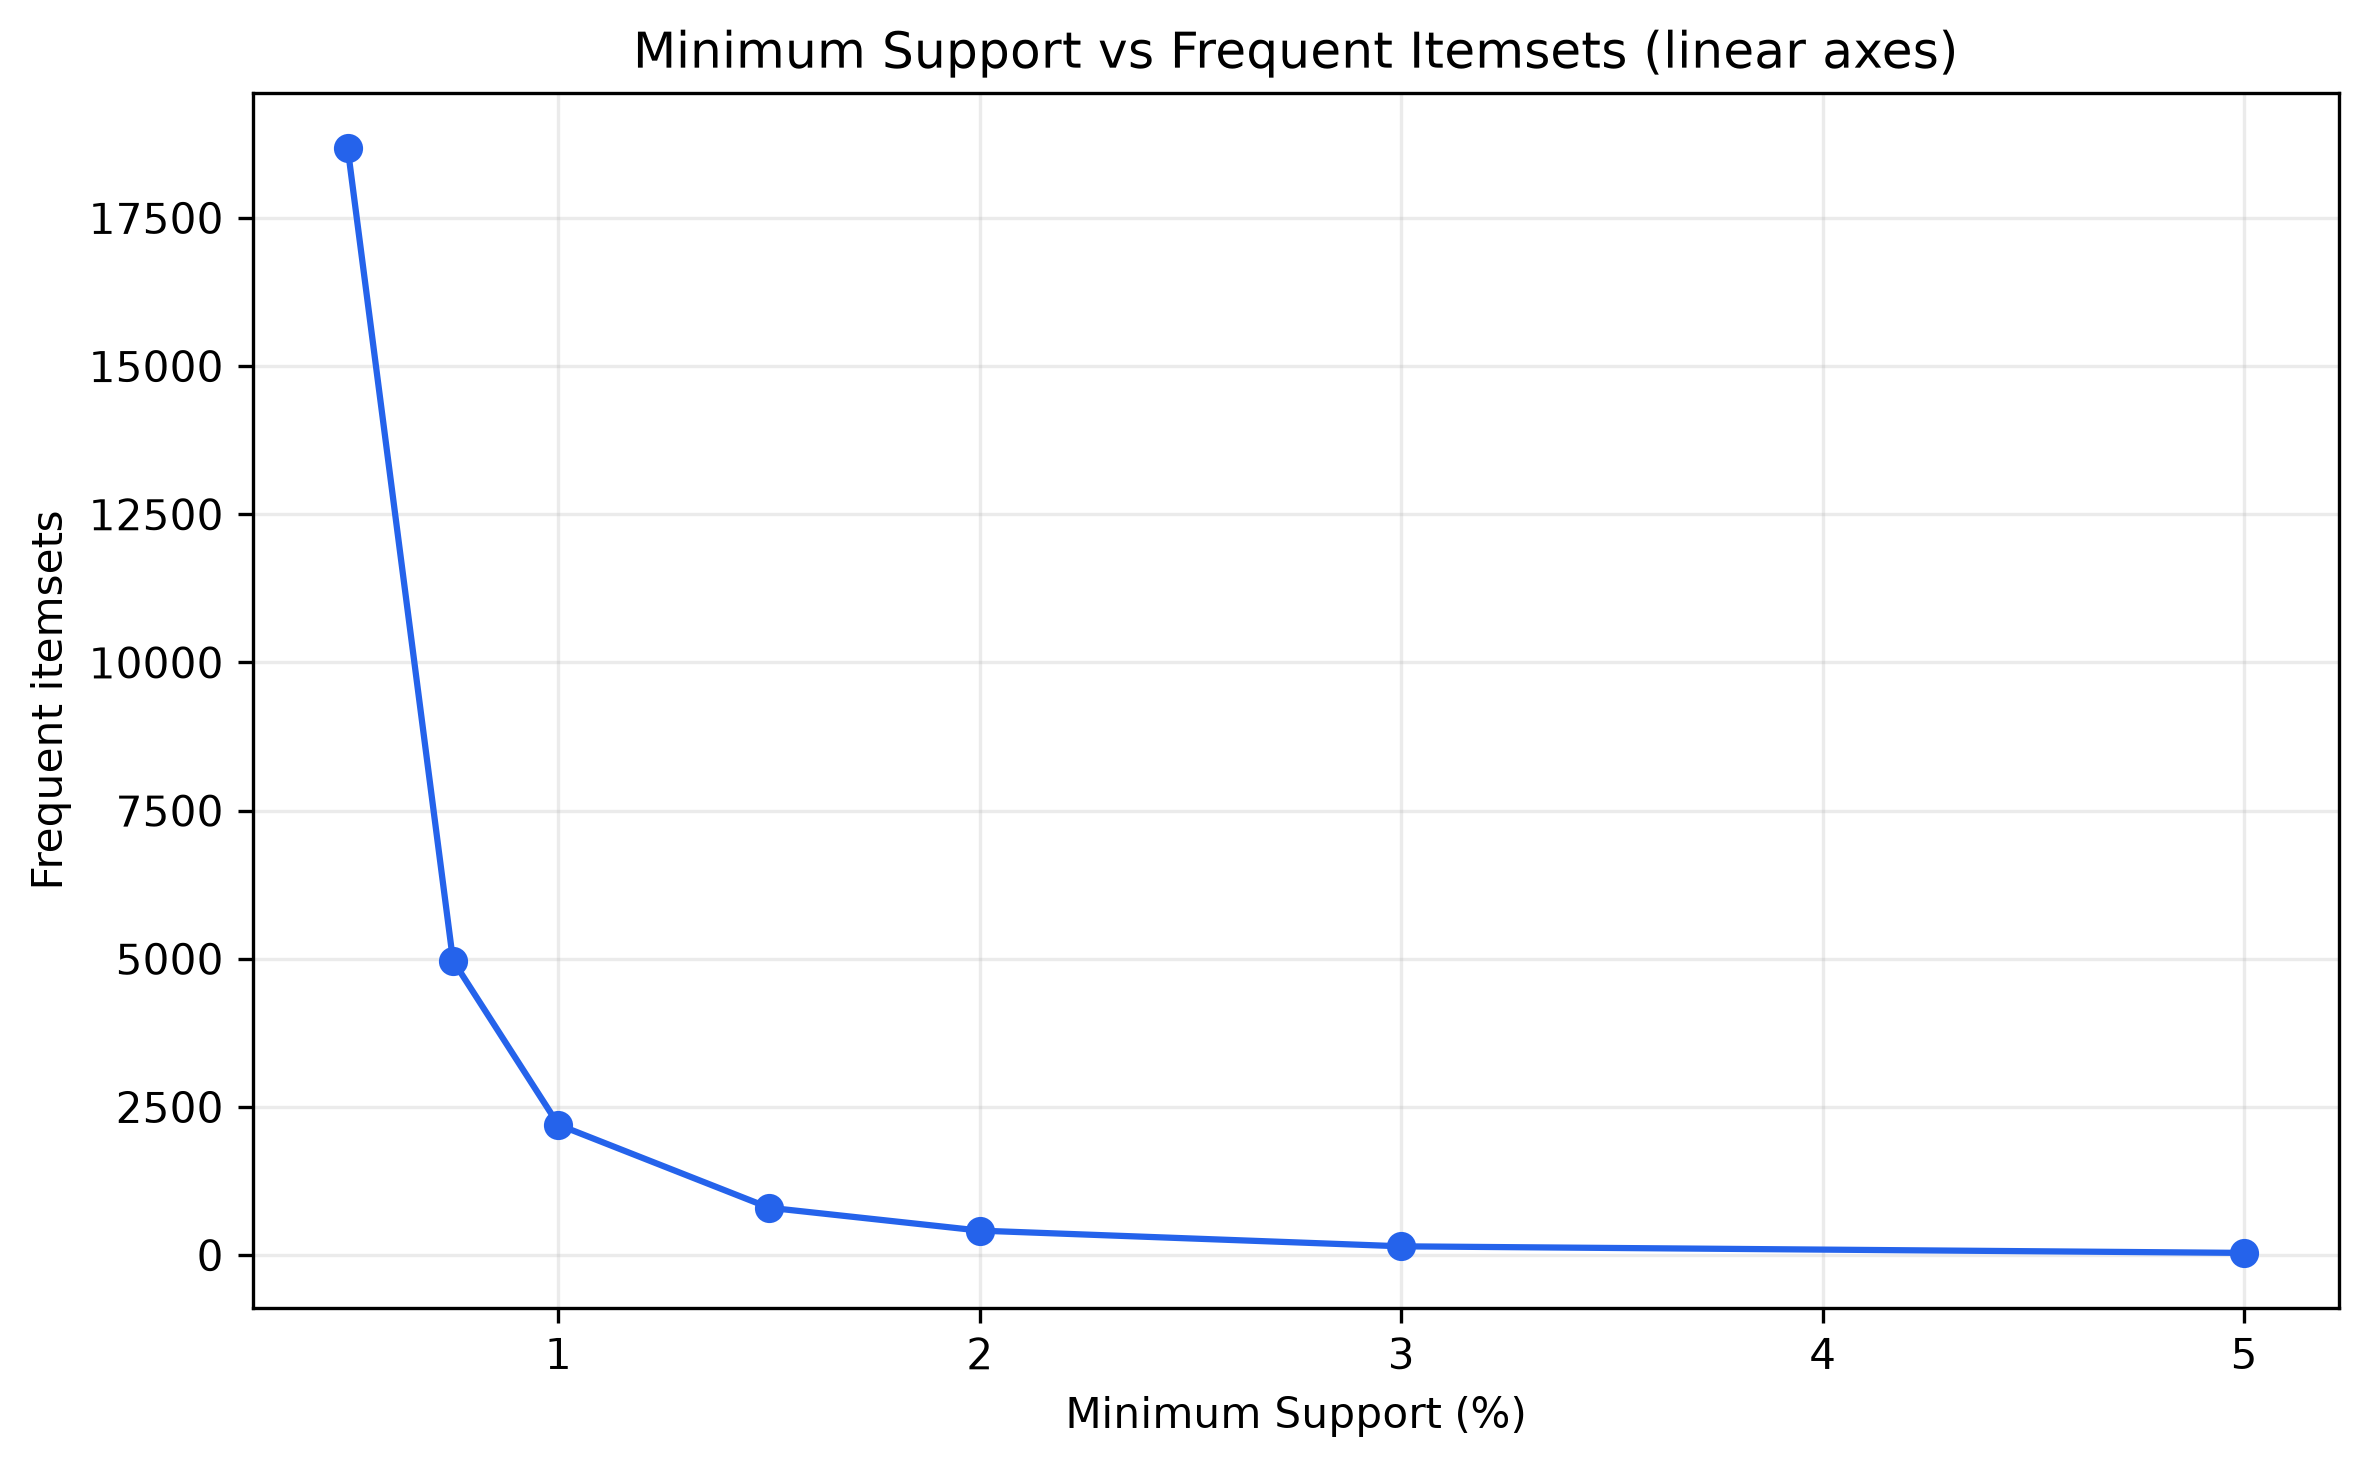

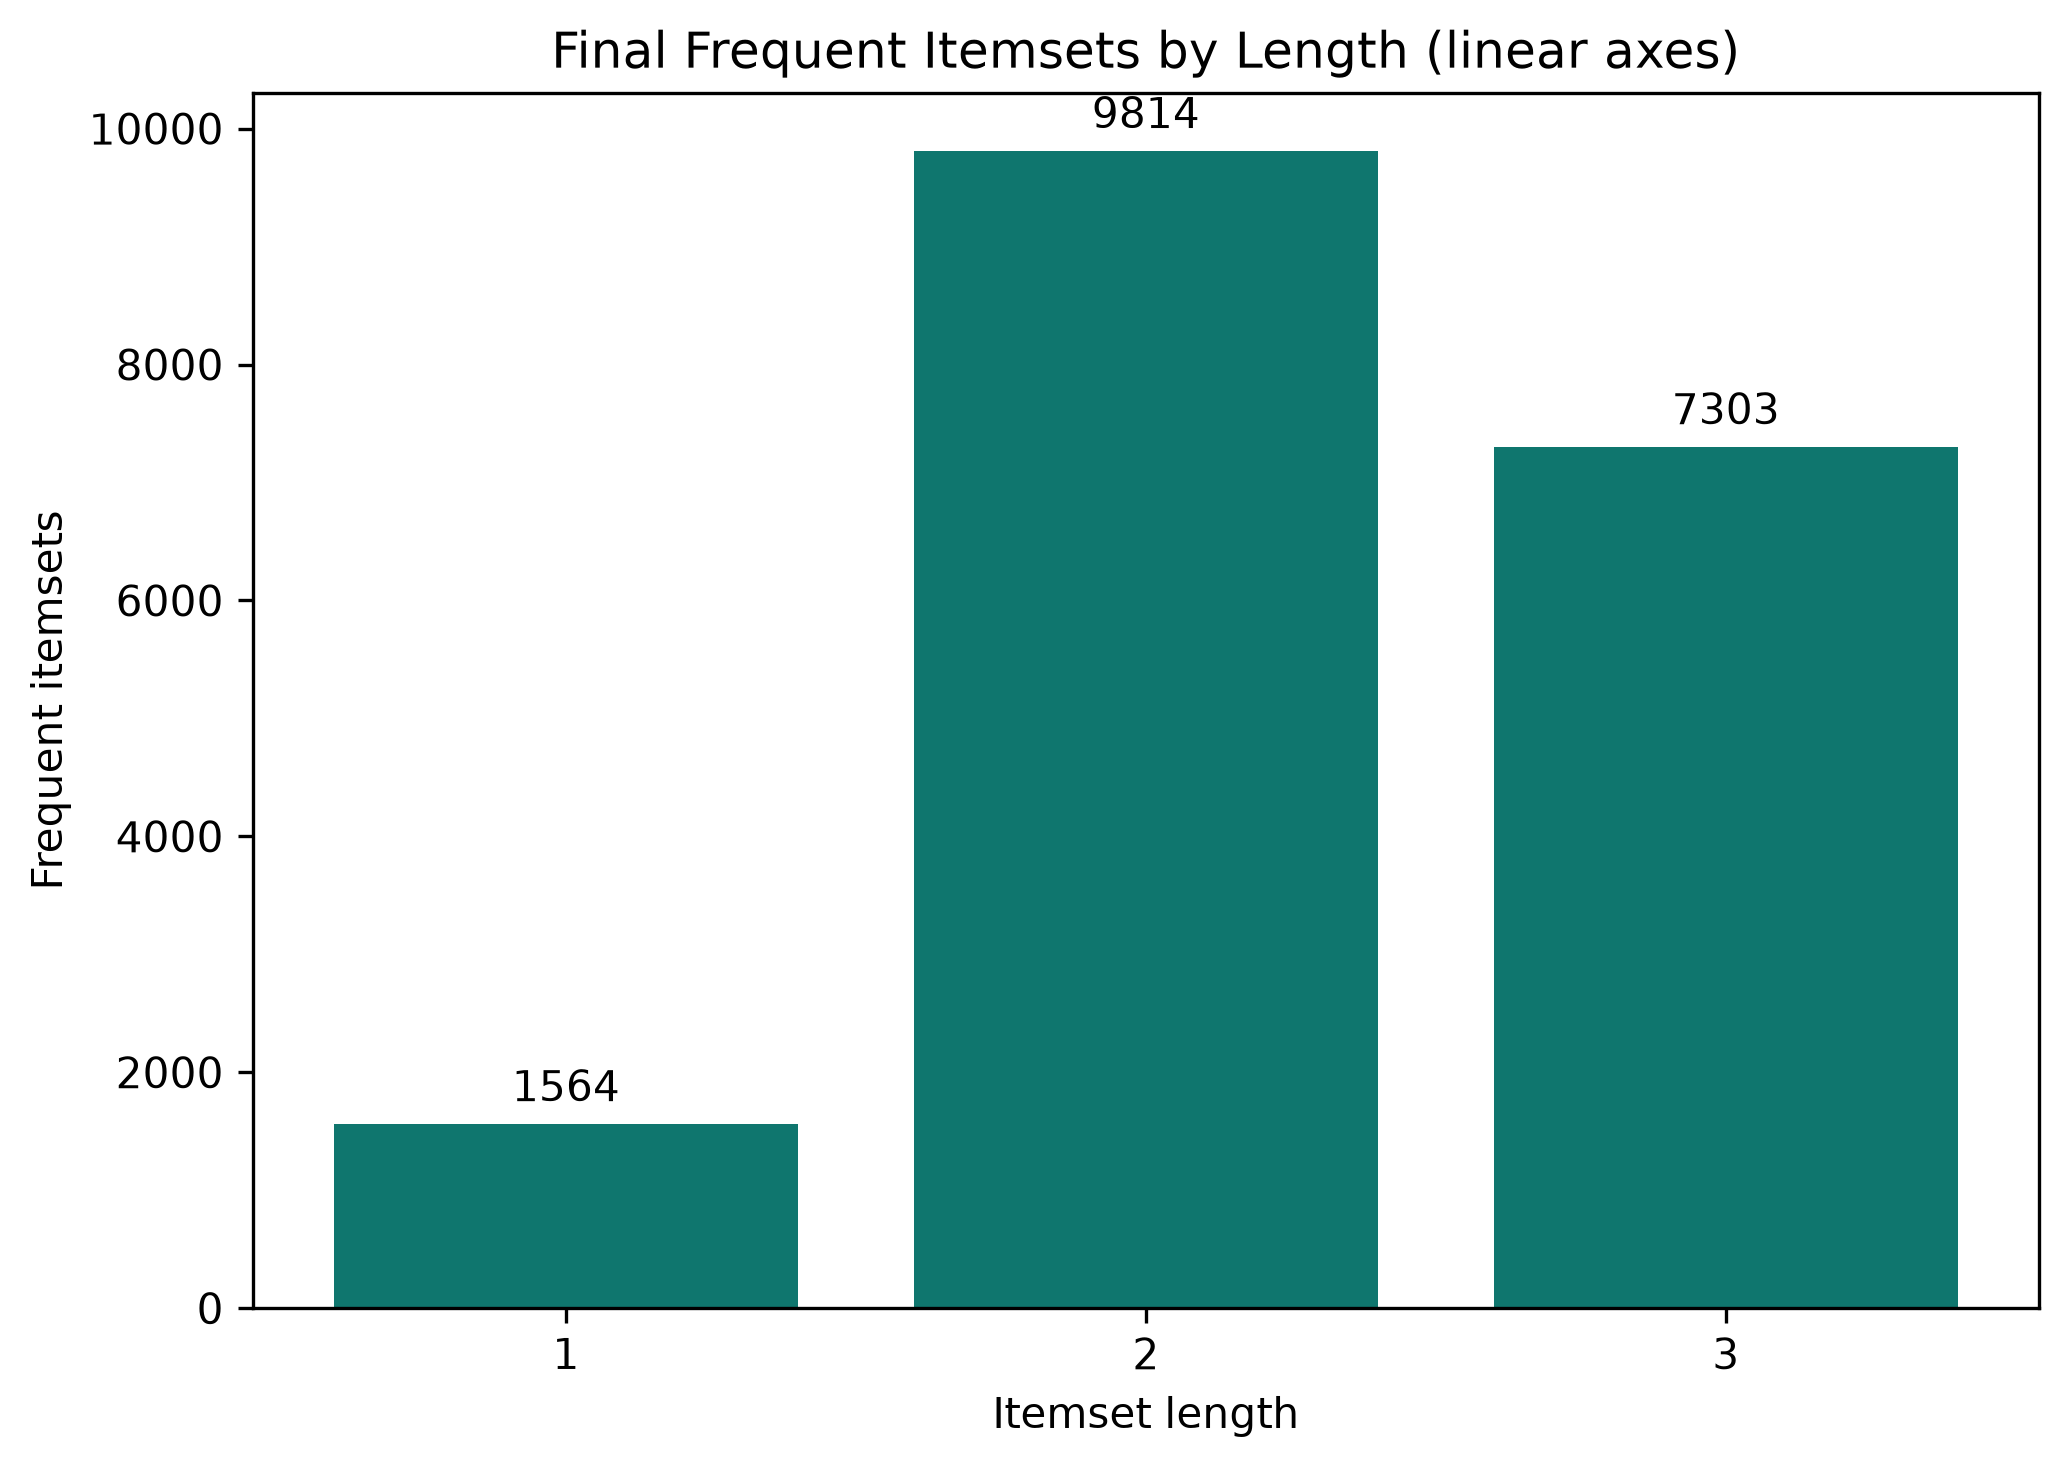

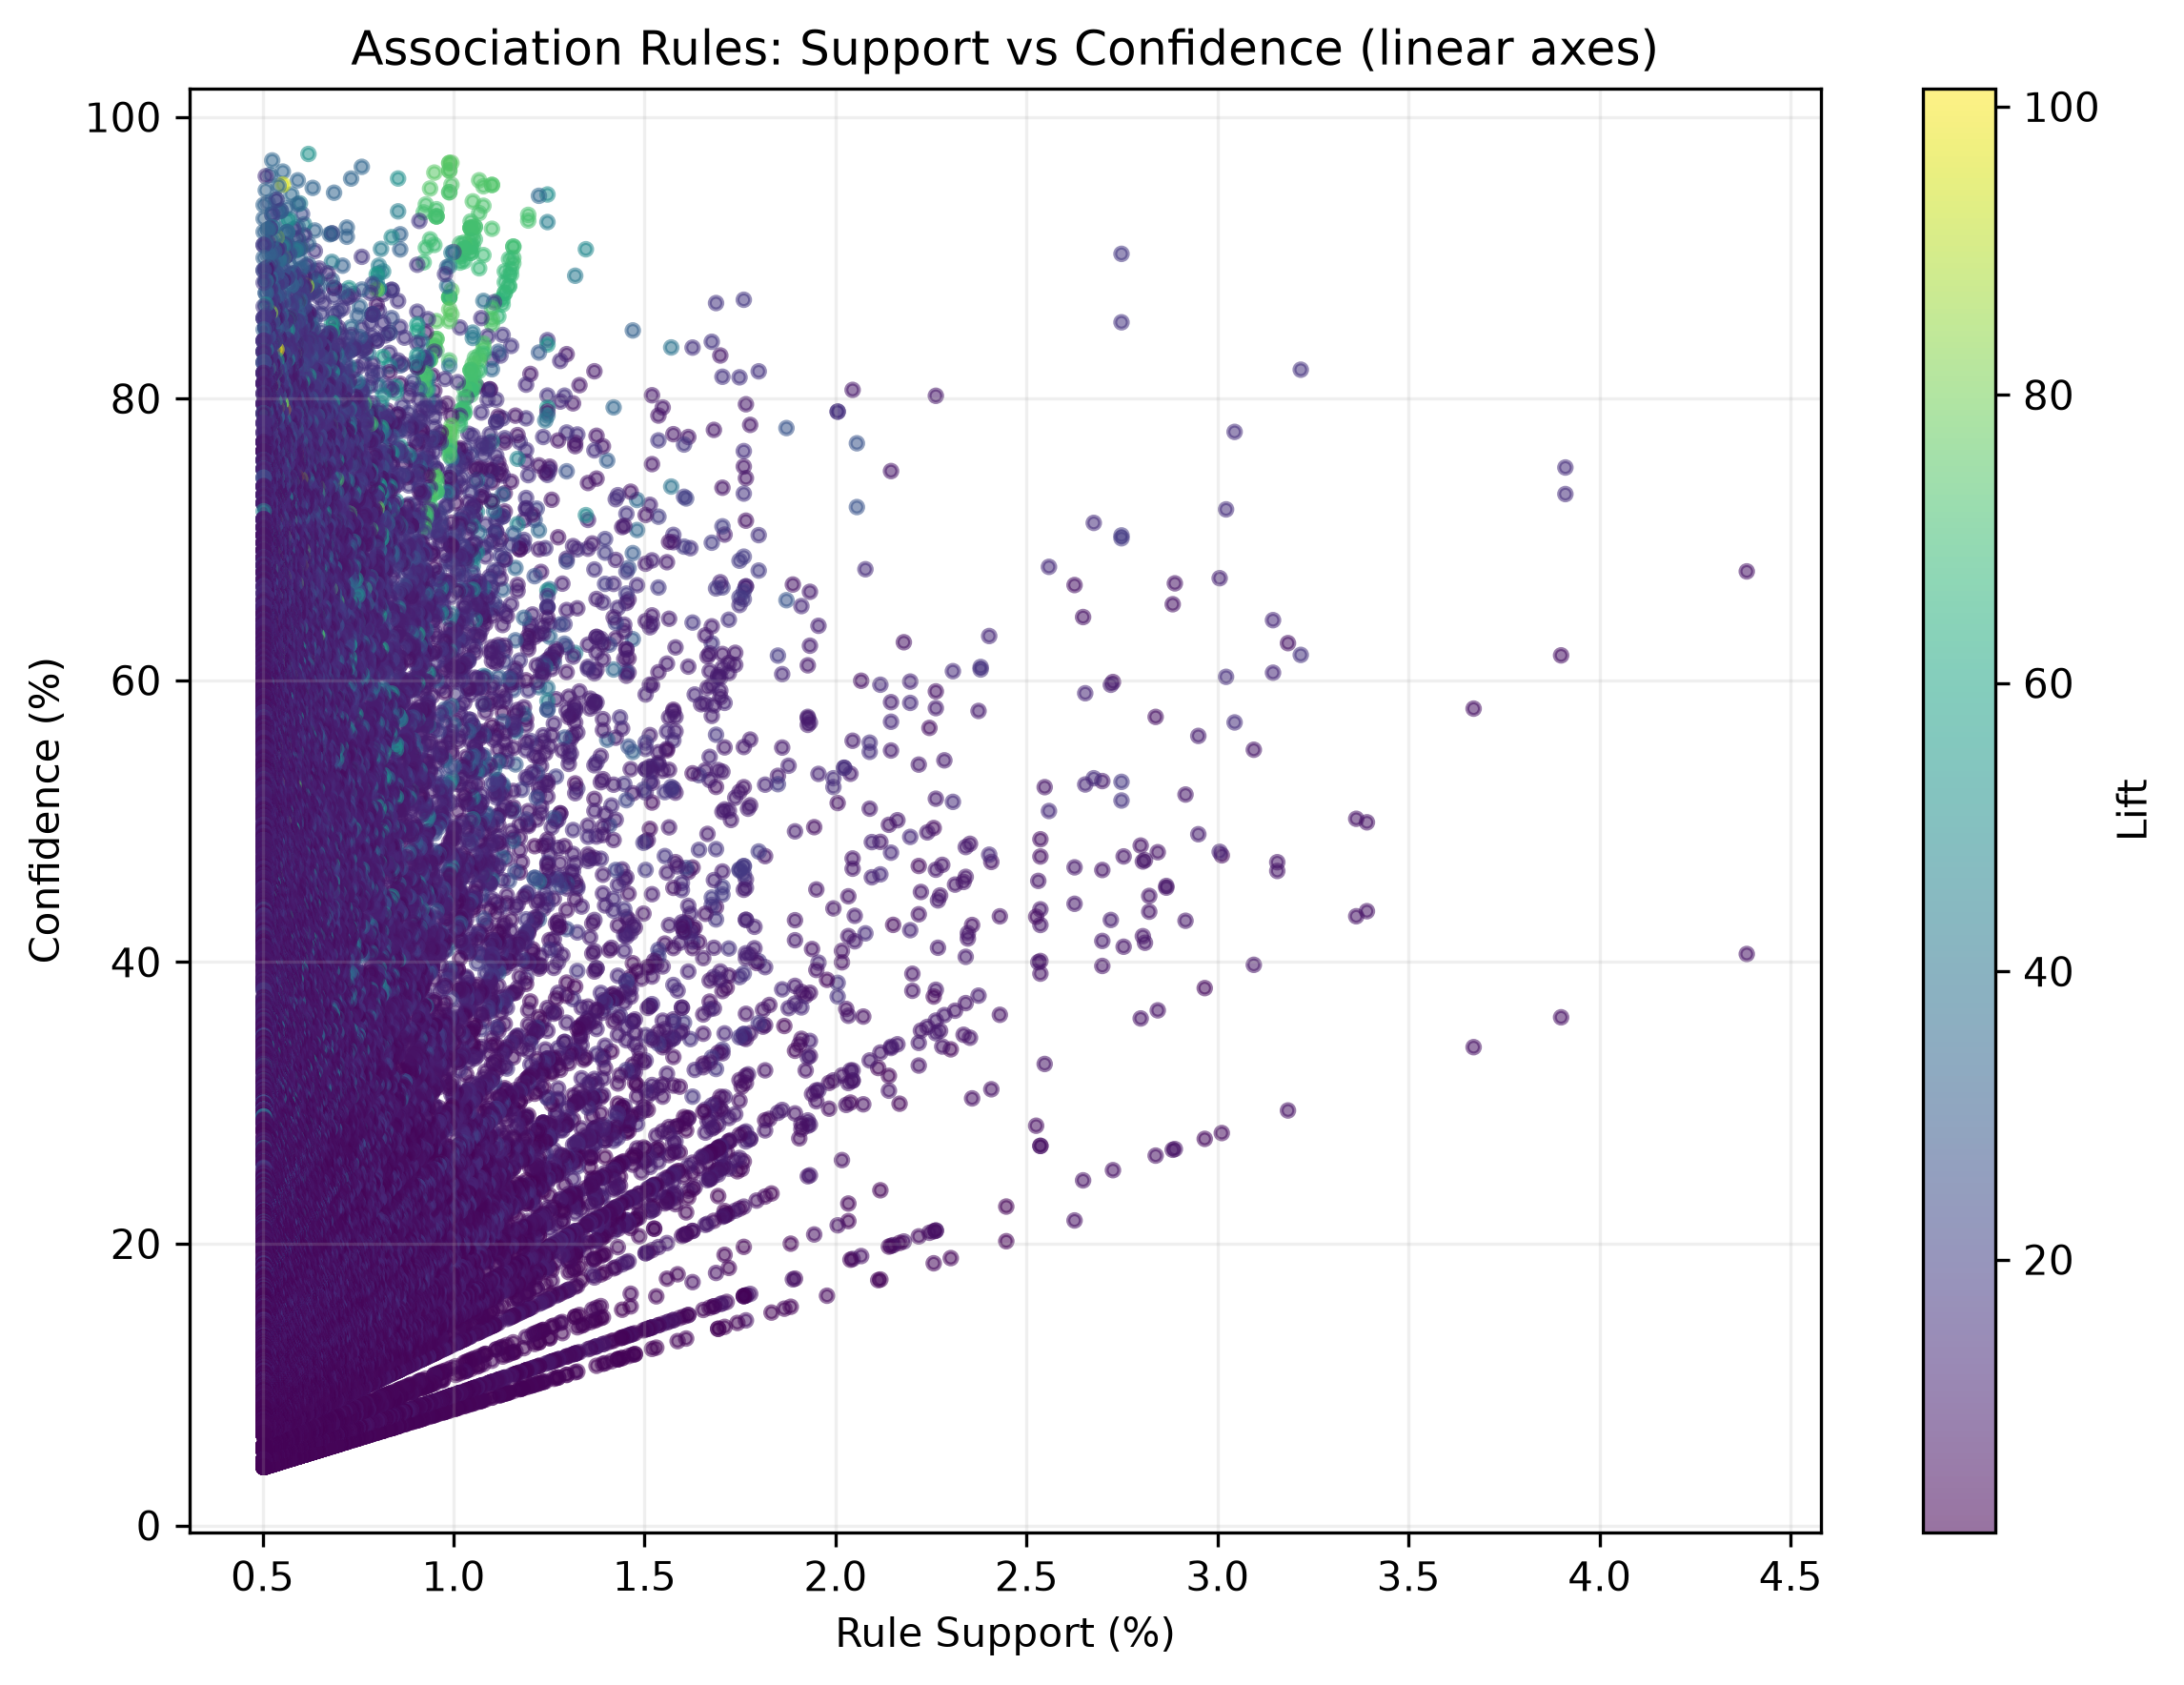

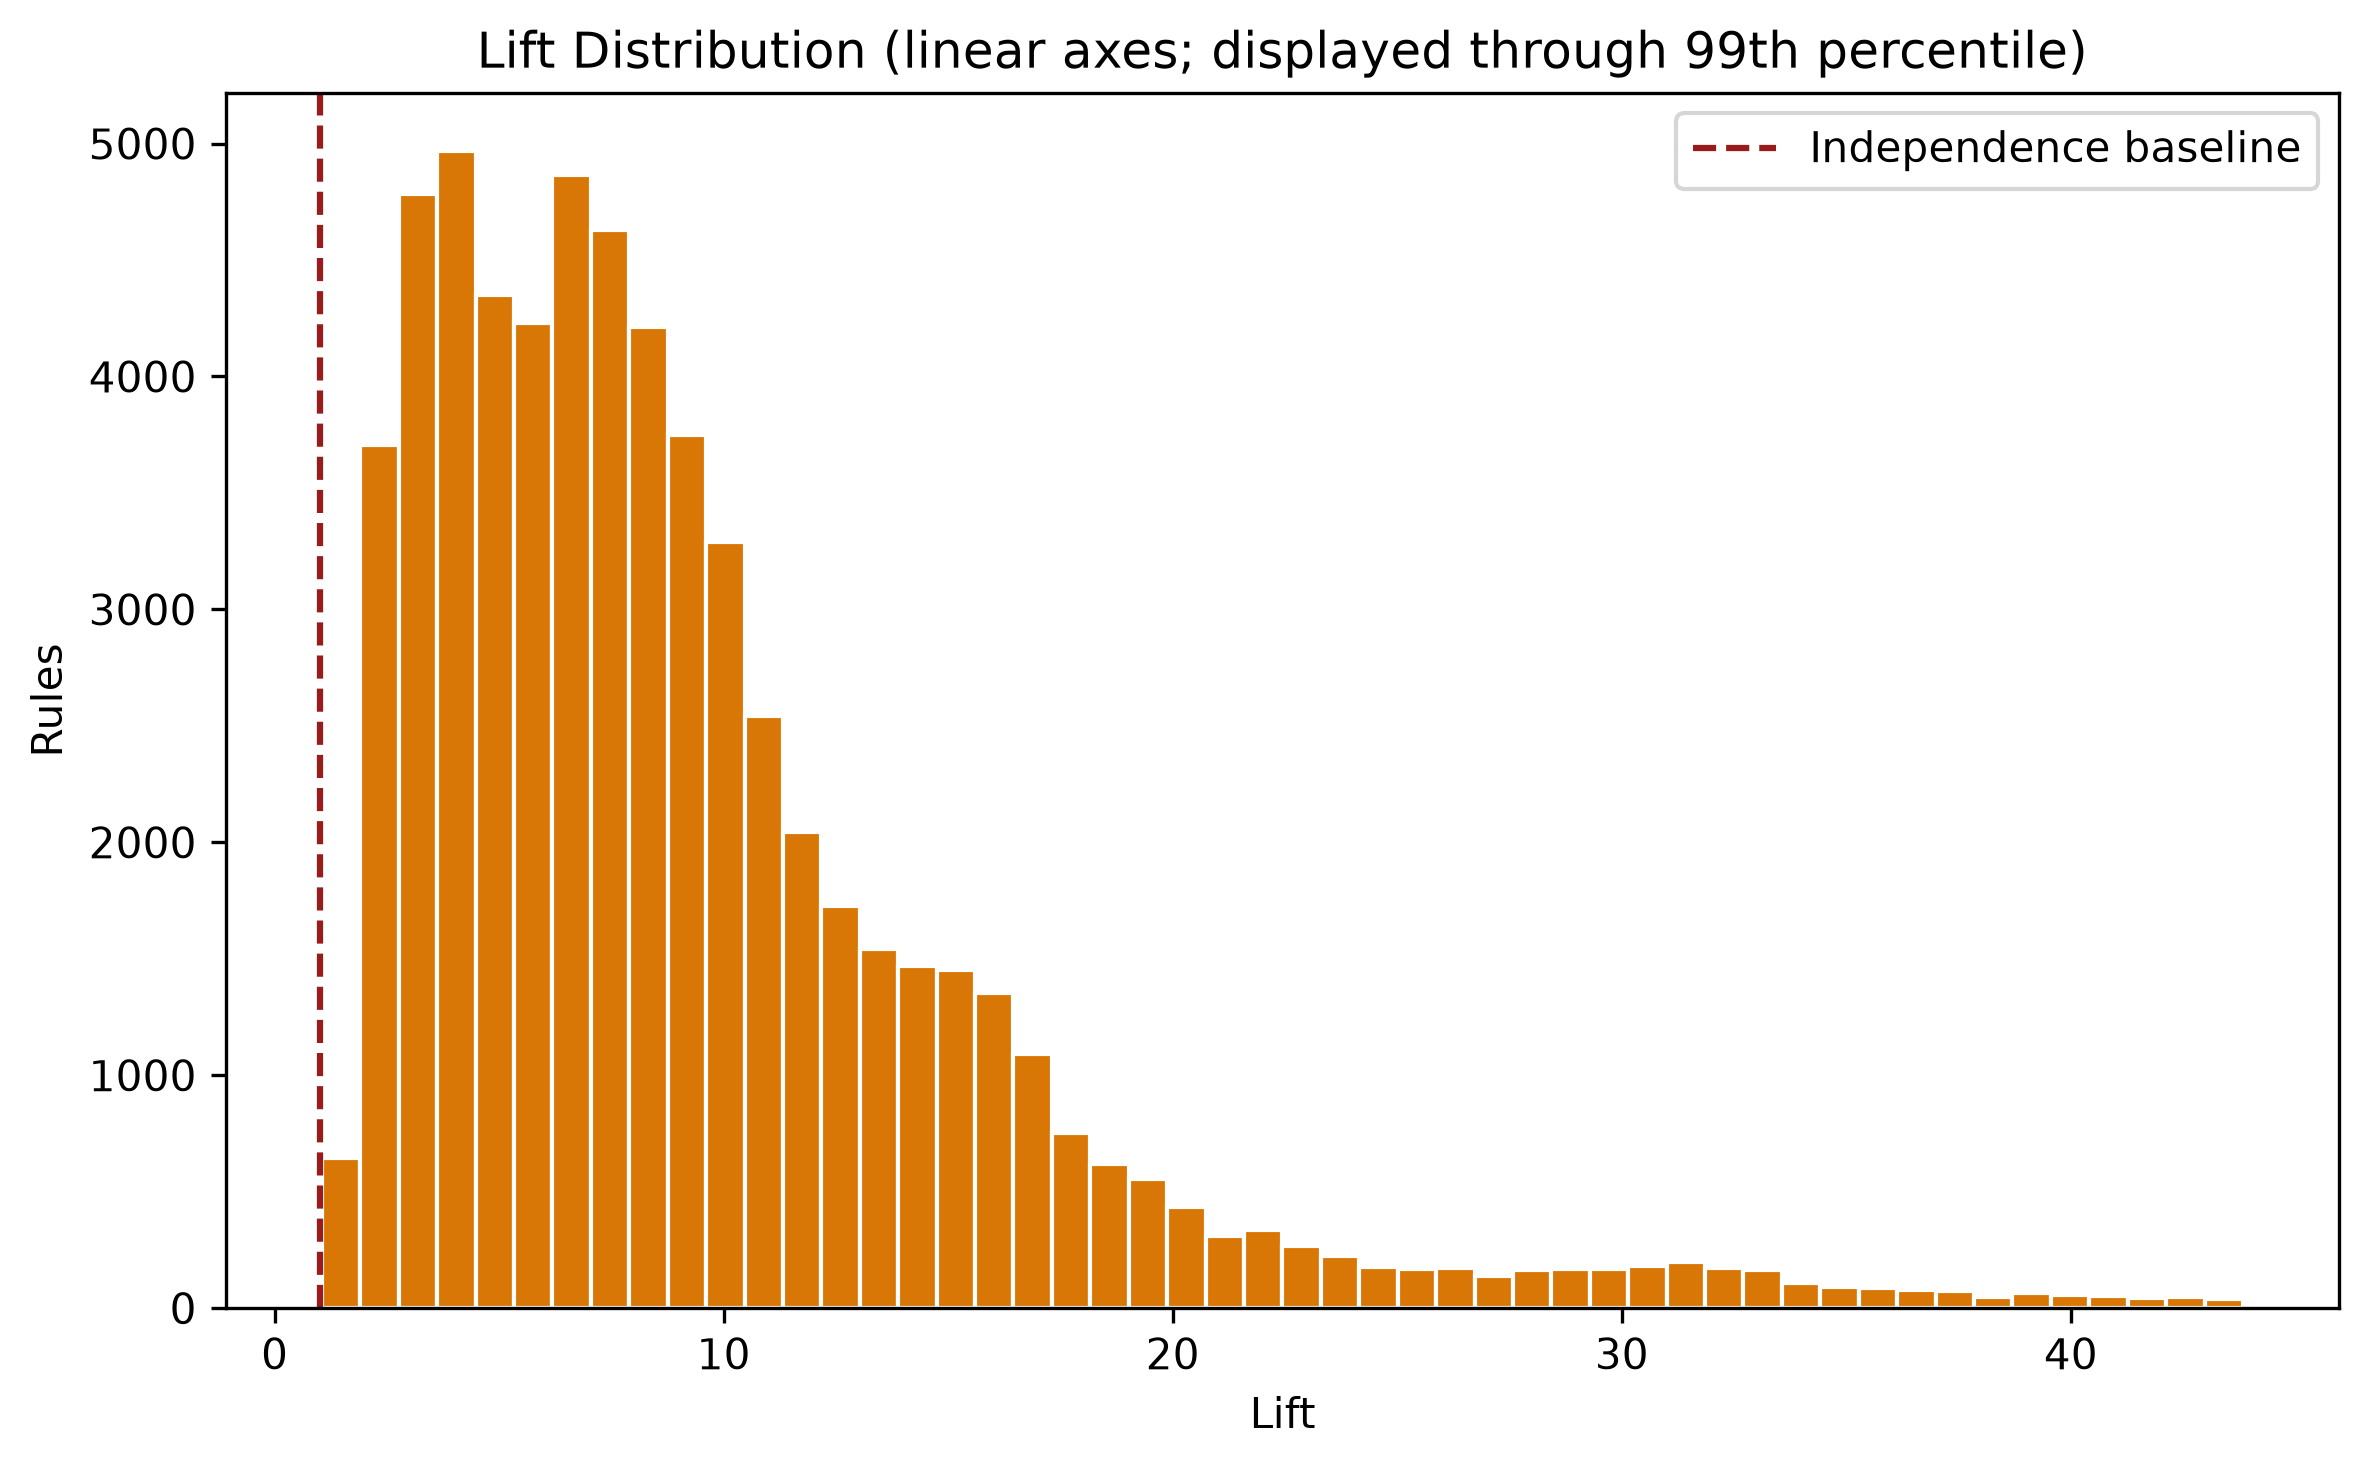

In [8]:
for filename in [
    "minimum_support_vs_frequent_itemsets.png",
    "frequent_itemsets_by_length.png",
    "association_rule_support_vs_confidence.png",
    "association_rule_lift_distribution.png",
]:
    display(Image(filename=str(project_path("outputs", "figures", filename)), width=900))

## القيود والاستعداد لـPhase 5

النتائج خاصة بنطاق UK وسياسة التنظيف وMinimum Support=0.5% و`max_len=3`. الارتباط لا يعني السببية، وارتفاع Lift عند دعم قريب من 90 معاملة يحتاج حذراً تجارياً. أصبحت الأنماط والقواعد والجداول جاهزة لمرحلة لاحقة تختبر الاستقرار وتبني أدوات تفاعلية؛ لم ينفذ هنا Bootstrap أو Product Association Network أو Basket Simulator أو WEKA.